#### Rule exploration and derived features - I

In [53]:
import numpy as np
import pandas as pd

In [54]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(2000, 14)

In [55]:
#   SOME IMPORTANT FINDINGS:

#   main_road_density + local_road_density = total_road_density
#   building_density + yellow_building_density = total_building_density
df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty'],
      dtype='str')

In [56]:
#   No Null values
df.isna().sum()

grid_id                    0
latitude                   0
longitude                  0
building_count             0
yellow_building_count      0
building_density           0
yellow_building_density    0
total_building_density     0
main_road_density          0
local_road_density         0
total_road_density         0
waterbody                  0
water_percent              0
empty                      0
dtype: int64

In [57]:
df.head()

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty
0,12666,28.492956,76.942579,0,0,0.00,0.0,0.00,0.0,0.00,0.00,0,0.0,100.00
1,59485,28.845094,77.292631,1,0,0.06,0.0,0.06,0.0,0.84,0.84,0,0.0,99.10
2,54194,28.805569,77.180041,7,0,0.71,0.0,0.71,0.0,7.81,7.81,0,0.0,91.48
3,31932,28.638483,76.918014,8,3,1.94,0.0,1.94,0.0,3.19,3.19,0,0.0,94.87
4,55722,28.818145,76.897543,16,0,2.85,0.0,2.85,0.0,2.94,2.94,0,0.0,94.21


In [58]:
#   Checking if any place where yellow_building is more than total_building_density
#   This would reflect data is WRONG

#   But from our analysis, this is not the case
df[df["yellow_building_density"] > df["total_building_density"]]

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty


In [59]:
#   Checking if any place where yellow_building is more than building_density
#   This would reflect data is WRONG

#   But from our analysis, this is not the case
df[
    abs(
        df["yellow_building_density"]
        + df["building_density"]
        - df["total_building_density"]
    )
    > 0.0001
]

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty


In [60]:
#   Checking how many data points have no buildings at all (0 buidling density)
df[df["total_building_density"] + df["yellow_building_density"] == 0]

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty
0,12666,28.492956,76.942579,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
8,6330,28.444447,77.126817,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
11,1588,28.408515,77.163665,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
12,46487,28.748077,76.993756,0,1,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
13,63070,28.872044,77.323337,0,0,0.0,0.0,0.0,0.00,2.90,2.90,0,0.0,97.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,52403,28.792992,76.924155,0,1,0.0,0.0,0.0,0.00,2.19,2.19,0,0.0,97.81
798,1138,28.404922,77.216889,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
799,20110,28.548652,77.077687,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0,0.0,100.00
826,35784,28.667229,77.008086,0,14,0.0,0.0,0.0,18.17,17.88,36.05,0,0.0,63.95


In [61]:
#   Checking if the below 2 mentioned columns are the same
#   CONCLUSION: building_density != total_building_density
df[abs(df["building_density"] - df["total_building_density"]) > 1].shape

(1158, 14)

In [62]:
#   This analysis confirms that:
#   main_road_density + local_road_density = total_road_density
#   building_density + yellow_building_density = total_building_density

df[
    abs(df["main_road_density"] + df["local_road_density"] - df["total_road_density"])
    > 0.0001
]

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty


In [63]:
#   All features to be used for now for GMM clustering

features = [
    "building_density",
    "other_building_proportion",  #   building_density / totoal_building_density
    "yellow_building_density",
    "yellow_building_proportion",  #   yellow_building_density / total_building_density
    "main_road_density",
    "main_road_proportion",  #   main_road_density / total_road_density
    "local_road_density",
    "local_road_proportion",  #   local_road_density / total_road_density
    "water_percent",
    "empty",
]

In [64]:
new_df = df.copy()
new_df.shape

(2000, 14)

In [65]:
def safe_divide(a, b):
    return np.where(b == 0, 0, a / b)

In [66]:
new_df["local_road_proportion"] = safe_divide(
    new_df["local_road_density"], new_df["total_road_density"]
)
new_df["main_road_proportion"] = safe_divide(
    new_df["main_road_density"], new_df["total_road_density"]
)

new_df["yellow_building_proportion"] = safe_divide(
    new_df["yellow_building_density"], new_df["total_building_density"]
)
new_df["other_building_proportion"] = safe_divide(
    new_df["building_density"], new_df["total_building_density"]
)

In [67]:
new_df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty',
       'local_road_proportion', 'main_road_proportion',
       'yellow_building_proportion', 'other_building_proportion'],
      dtype='str')

In [68]:
# cols_to_drop = ['grid_id', 'latitude', 'longitude', 'building_count', 'yellow_building_count', 'waterbody']
# new_df.drop(cols_to_drop, axis=1, inplace=True)

# print(new_df.columns)

## GMM starts here:

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [70]:
cols_to_drop = [
    "grid_id",
    "latitude",
    "longitude",
    "building_count",
    "yellow_building_count",
    "waterbody",
]
X_scaled = StandardScaler().fit_transform(new_df.drop(cols_to_drop, axis=1))
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
labels = gmm.fit_predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

In [71]:
new_df["labels"] = labels
for i in range(probs.shape[1]):
    new_df[f"prob_cluster_{i}"] = probs[:, i]

In [72]:
new_df.sort_values(by="grid_id", inplace=True)
new_df.to_csv(
    "/Users/saranyapal/Developer/grid-determination-bizom/outputs/results_gmm_sorted.csv"
)

In [73]:
#   Labels:
#   Label = 0: Low Potential
#   Label = 1: High Potential
#   Label = 2: Medium Potential

new_df[["grid_id", "labels"]].reset_index(drop=True).head(10)

,grid_id,labels
0,157,0
1,209,1
2,221,1
3,222,1
4,230,1
5,233,1
6,242,0
7,309,1
8,328,1
9,454,1


In [74]:
new_df[["grid_id", "labels"]][new_df["labels"] == 2].reset_index(drop=True).head(10)

,grid_id,labels
0,10367,2
1,11404,2
2,11483,2
3,11658,2
4,18339,2
5,19031,2
6,21407,2
7,22020,2
8,23786,2
9,25402,2


In [75]:
new_df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty',
       'local_road_proportion', 'main_road_proportion',
       'yellow_building_proportion', 'other_building_proportion', 'labels',
       'prob_cluster_0', 'prob_cluster_1', 'prob_cluster_2'],
      dtype='str')

In [76]:
new_df.head()

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,...,water_percent,empty,local_road_proportion,main_road_proportion,yellow_building_proportion,other_building_proportion,labels,prob_cluster_0,prob_cluster_1,prob_cluster_2
487,157,28.397735,77.157523,0,0,0.00,0.00,0.00,0.00,0.00,...,0.0,100.00,0.000000,0.000000,0.000000,0.000000,0,1.0,0.000000,3.994641e-09
221,209,28.397735,77.263972,12,3,8.39,0.00,8.39,0.32,5.20,...,0.0,86.09,0.942029,0.057971,0.000000,1.000000,1,0.0,0.999998,2.495259e-06
1027,221,28.397735,77.288537,80,5,26.11,0.72,26.83,9.58,11.21,...,0.0,52.38,0.539202,0.460798,0.026836,0.973164,1,0.0,1.000000,1.219758e-16
1475,222,28.397735,77.290584,61,14,41.38,2.90,44.28,0.51,12.68,...,0.0,42.53,0.961334,0.038666,0.065492,0.934508,1,0.0,1.000000,2.972198e-133
1129,230,28.397735,77.306961,47,8,33.17,4.63,37.80,8.47,13.82,...,0.0,39.91,0.620009,0.379991,0.122487,0.877513,1,0.0,1.000000,0.000000e+00


### Visualization

In [77]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

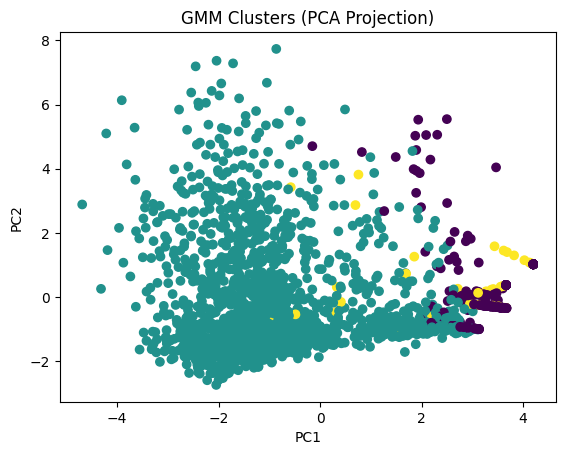

In [78]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (PCA Projection)")
plt.show()

### Problems and Issues:
**TODO: Figure out examples and note them down (grid_ids) of each of these cases**

The above method is a good starting point; however there are several issues:
1. For eg: 63970 -> Classified as "medium potential", but should be "low potential"
2. Upon observation, it was found that "water pecent" is adding noise to the prediction labels
3. All images with very high water covearge is getting "medium potential" label. It is not correct
    - Need to find out land density percent (may not need images to be analyzed) (land percent = total - water percent)
    - Or probably, a better approach is to derive a feature: undeveloped_area = empty + water_percent. That is a better indicator of signal
    - The reason water percent adds noise bcz. the inverse of this is probably a signal
    - But for clustering, they act as distance-based (higher value, further distance)
    - So, as soon as we reverse the signal, it will probably help us to capture the pattern, rather than acting as noise

4. Coming to the next problem, there are cases where dense buildings are present, but yellow patches are scarse. They probably refer to industrial complexes etc. Kirana stores has less potential in these places; kirana stores will thrive only in places where there are residential complexes

### Question to be asked:
1. What is the meaning of "high potential"? Is it from kirana-store perspective?
2. For eg: "Good" as having high residential/kirana presence (yellow buildings) vs
"Good" -> industrial location etc

3. I personally assume: that "high potential" is from kirana-store perspective.
That means, an industrial dense area may not have a "high potential". Kirana-stores
are present in localities, near households. And seldom near industrial complexes...


### Identifying the exact false examples:

1. High Empty Area:
- 36251 (labelled 2 - should be 0) 
- 59442 (labelled 1 - should be 0) 
- 45771 (labelled 2 - should be 0)
- 33050 (labelled 1 - should be 0)
- 63146 (labelled 2 - should be 0)
- 50531 (labelled 1 - should be 0)
- 22020 (labelled 2 - should be 0)
- 40546 (labelled 1 - should be 0)
- 29203 (labelled 2 - should be 0)